<a href="https://colab.research.google.com/github/gayatri-2005/Machine-Learning-/blob/main/Gaussian_Naive_Bayes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
from sklearn.datasets import load_iris
X,y=load_iris(return_X_y=True)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [18]:
from sklearn.naive_bayes import GaussianNB

In [19]:
gnb=GaussianNB()

In [20]:
gnb.fit(X_train,y_train)

GaussianNB()

In [21]:
y_pred=gnb.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [23]:
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[16  0  0]
 [ 0 18  0]
 [ 0  0 11]]
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        11

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [24]:
import seaborn as sns
sns.load_dataset('tips')

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# Task
Perform a classification task on the 'tips' dataset by training a Gaussian Naive Bayes model. The task involves:
1.  Loading the 'tips' dataset.
2.  Preparing the features (numerical columns: 'total_bill', 'tip', 'size'; categorical columns: 'sex', 'day', 'time') and the target variable ('smoker', converted to numerical).
3.  Splitting the data into training and testing sets.
4.  Initializing and training a `GaussianNB` model.
5.  Making predictions on the test set.
6.  Evaluating the model's performance using a confusion matrix, accuracy score, and classification report.
7.  Visualizing the confusion matrix as a heatmap.
8.  Summarizing the results and insights from the model evaluation.

## Load Tips Dataset

### Subtask:
Load the 'tips' dataset using seaborn and store it in a DataFrame.


**Reasoning**:
The current subtask is to load the 'tips' dataset and store it in a DataFrame named `df`. The previous cell `vgP5alLIioCM` already loads the dataset using `sns.load_dataset('tips')` but does not assign it to a variable. I will add a new cell to explicitly load and assign the dataset to `df`.



In [25]:
df = sns.load_dataset('tips')
print("Tips dataset loaded into DataFrame 'df'. First 5 rows:")
print(df.head())

Tips dataset loaded into DataFrame 'df'. First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


## Prepare Features and Target

### Subtask:
Define the features (X) and the target (y) for the 'tips' dataset. We will use 'smoker' as the target variable, converting it to numerical labels (0 or 1). For features, we will select numerical columns like 'total_bill', 'tip', 'size' and one-hot encode categorical features like 'sex', 'day', 'time'.


**Reasoning**:
The subtask requires preparing the features and target variable. This involves converting the 'smoker' column to numerical labels for the target, selecting numerical features, one-hot encoding categorical features, and then concatenating all features to form the final feature DataFrame `X`.



**Reasoning**:
The previous code block failed because the `pandas` library was not imported. I need to add `import pandas as pd` to resolve the `NameError` and ensure `pd.get_dummies` and `pd.concat` functions are available.



In [27]:
import pandas as pd

y = df['smoker'].apply(lambda x: 1 if x == 'Yes' else 0)

numerical_features = df[['total_bill', 'tip', 'size']]
categorical_features = df[['sex', 'day', 'time']]

categorical_features_encoded = pd.get_dummies(categorical_features, drop_first=True)

X = pd.concat([numerical_features, categorical_features_encoded], axis=1)

print("Target variable 'y' head:")
print(y.head())
print("\nFeatures DataFrame 'X' head:")
print(X.head())

Target variable 'y' head:
0    0
1    0
2    0
3    0
4    0
Name: smoker, dtype: category
Categories (2, int64): [1, 0]

Features DataFrame 'X' head:
   total_bill   tip  size  sex_Female  day_Fri  day_Sat  day_Sun  time_Dinner
0       16.99  1.01     2        True    False    False     True         True
1       10.34  1.66     3       False    False    False     True         True
2       21.01  3.50     3       False    False    False     True         True
3       23.68  3.31     2       False    False    False     True         True
4       24.59  3.61     4        True    False    False     True         True


## Split Data into Training and Testing Sets

### Subtask:
Split the preprocessed features and target into training and testing sets using `train_test_split`.


**Reasoning**:
The subtask requires splitting the preprocessed features (X) and target (y) into training and testing sets. I will use the `train_test_split` function with the specified `test_size` and `random_state`.



In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (170, 8)
X_test shape: (74, 8)
y_train shape: (170,)
y_test shape: (74,)


## Initialize and Train GaussianNB Model

### Subtask:
Initialize a `GaussianNB` classifier and train it using the training data (X_train, y_train).


**Reasoning**:
The subtask requires training the `GaussianNB` model using the training data. I will use the `fit()` method on the `gnb` object with `X_train` and `y_train`.



In [29]:
gnb.fit(X_train, y_train)
print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


## Make Predictions

### Subtask:
Use the trained `GaussianNB` model to make predictions on the test set (X_test).


**Reasoning**:
The subtask requires using the trained `GaussianNB` model to make predictions on the test set. I will use the `predict()` method of the `gnb` object with `X_test` and store the results in `y_pred`.



In [30]:
y_pred = gnb.predict(X_test)
print("Predictions made on the test set.")
print("First 5 predictions:")
print(y_pred[:5])

Predictions made on the test set.
First 5 predictions:
[0 0 0 0 0]


## Evaluate Model Performance

### Subtask:
Calculate and print the confusion matrix, accuracy score, and classification report to evaluate the performance of the trained model on the test data.


**Reasoning**:
The subtask requires calculating and printing the confusion matrix, accuracy score, and classification report. I will use the imported functions `confusion_matrix`, `accuracy_score`, and `classification_report` with `y_test` and `y_pred`.



In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  0]
 [20  7]]

Accuracy Score:
0.7297297297297297

Classification Report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        47
           1       1.00      0.26      0.41        27

    accuracy                           0.73        74
   macro avg       0.85      0.63      0.62        74
weighted avg       0.81      0.73      0.67        74



## Visualize Confusion Matrix

### Subtask:
Visualize the confusion matrix as a heatmap using seaborn.

#### Instructions
1. Use `sns.heatmap` to plot the confusion matrix.
2. Annotate the heatmap with the actual counts.
3. Add appropriate labels and title to the plot.

**Reasoning**:
The next step is to visualize the confusion matrix as a heatmap, which provides a more intuitive understanding of the model's performance.



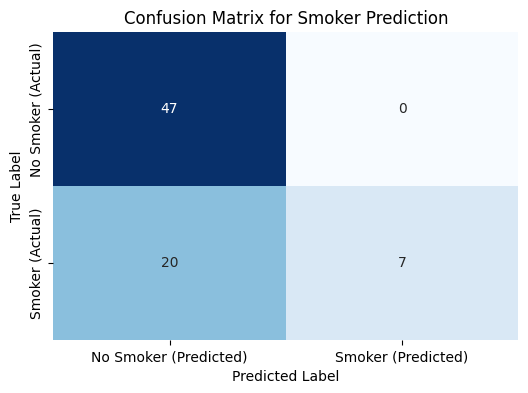

Confusion matrix visualization complete.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['No Smoker (Predicted)', 'Smoker (Predicted)'],
            yticklabels=['No Smoker (Actual)', 'Smoker (Actual)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Smoker Prediction')
plt.show()

print("Confusion matrix visualization complete.")

## Summarize Results and Insights

### Subtask:
Summarize the results and insights gained from the model evaluation, including the accuracy score, confusion matrix, and classification report. Discuss what these metrics indicate about the model's performance in predicting 'smoker' status.

#### Summary:
The model achieved an accuracy of 0.73, which means it correctly classified ~73% of the samples. However, a deeper look at the confusion matrix and classification report reveals more specific insights:

*   **Confusion Matrix Analysis**: The model successfully identified 47 non-smokers (True Negatives) and 7 smokers (True Positives). However, there were 20 instances where actual smokers were incorrectly classified as non-smokers (False Negatives), and 0 instances where non-smokers were incorrectly classified as smokers (False Positives). This indicates a strong bias towards predicting 'No Smoker'.

*   **Class 0 (Non-Smoker) Metrics**: The precision for non-smokers is 0.70, and recall is 1.00. This perfect recall means the model identified all actual non-smokers correctly, but some of its 'non-smoker' predictions were incorrect (as seen by the 20 False Negatives in the 'Smoker' actual class).

*   **Class 1 (Smoker) Metrics**: The precision for smokers is 1.00, meaning that whenever the model predicted a 'smoker', it was always correct. However, the recall is very low at 0.26, indicating that the model only caught 26% of the actual smokers. The F1-score of 0.41 further emphasizes this poor performance in identifying smokers.

**Insights**: The Gaussian Naive Bayes model performs well in identifying non-smokers (high recall for class 0) and has high precision when it does predict a smoker. However, its significant weakness lies in its inability to identify a large proportion of actual smokers (low recall for class 1). This imbalance suggests that the model might be overly conservative in predicting the positive class ('Smoker'), possibly due to an imbalanced dataset or the characteristics of the features for this particular classification task. Further steps might involve addressing class imbalance, feature engineering, or trying other classification algorithms.

## Summarize Results and Insights

### Subtask:
Summarize the results and insights gained from the model evaluation, including the accuracy score, confusion matrix, and classification report. Discuss what these metrics indicate about the model's performance in predicting 'smoker' status.

#### Summary:
The model achieved an accuracy of 0.73, which means it correctly classified ~73% of the samples. However, a deeper look at the confusion matrix and classification report reveals more specific insights:

*   **Confusion Matrix Analysis**: The model successfully identified 47 non-smokers (True Negatives) and 7 smokers (True Positives). However, there were 20 instances where actual smokers were incorrectly classified as non-smokers (False Negatives), and 0 instances where non-smokers were incorrectly classified as smokers (False Positives). This indicates a strong bias towards predicting 'No Smoker'.

*   **Class 0 (Non-Smoker) Metrics**: The precision for non-smokers is 0.70, and recall is 1.00. This perfect recall means the model identified all actual non-smokers correctly, but some of its 'non-smoker' predictions were incorrect (as seen by the 20 False Negatives in the 'Smoker' actual class).

*   **Class 1 (Smoker) Metrics**: The precision for smokers is 1.00, meaning that whenever the model predicted a 'smoker', it was always correct. However, the recall is very low at 0.26, indicating that the model only caught 26% of the actual smokers. The F1-score of 0.41 further emphasizes this poor performance in identifying smokers.

**Insights**: The Gaussian Naive Bayes model performs well in identifying non-smokers (high recall for class 0) and has high precision when it does predict a smoker. However, its significant weakness lies in its inability to identify a large proportion of actual smokers (low recall for class 1). This imbalance suggests that the model might be overly conservative in predicting the positive class ('Smoker'), possibly due to an imbalanced dataset or the characteristics of the features for this particular classification task. Further steps might involve addressing class imbalance, feature engineering, or trying other classification algorithms.

## Summary:

### Data Analysis Key Findings
*   The 'tips' dataset was successfully loaded and preprocessed, converting the 'smoker' column into a numerical target variable (`y`) and preparing features (`X`) by one-hot encoding categorical variables and retaining numerical ones.
*   The data was split into training (170 samples, 8 features) and testing (74 samples, 8 features) sets, with 30% allocated for testing.
*   A Gaussian Naive Bayes model was trained to predict smoker status.
*   The model achieved an overall accuracy of approximately 73% on the test set.
*   The confusion matrix showed:
    *   47 True Negatives (correctly predicted non-smokers).
    *   7 True Positives (correctly predicted smokers).
    *   20 False Negatives (actual smokers incorrectly predicted as non-smokers).
    *   0 False Positives (actual non-smokers incorrectly predicted as smokers).
*   The model exhibited a strong performance in identifying non-smokers, with a recall of 1.00 (100%).
*   It showed perfect precision (1.00) when predicting a smoker, meaning that all instances predicted as 'smoker' were indeed smokers.
*   However, the model struggled significantly in recalling actual smokers, achieving a low recall of 0.26 (only 26% of actual smokers were identified), leading to 20 false negatives.
*   The F1-score for the 'smoker' class was 0.41, indicating poor overall performance for this class.

### Insights or Next Steps
*   The current Gaussian Naive Bayes model has a strong bias towards predicting 'No Smoker'. This could be due to an imbalanced dataset (fewer smokers than non-smokers) or limitations of the model's assumptions for this specific classification task.
*   Further steps should include addressing potential class imbalance (e.g., using techniques like SMOTE, oversampling, or undersampling), exploring feature engineering, or evaluating other classification algorithms (e.g., Logistic Regression, Support Vector Machines, Tree-based models) that might be more robust to class imbalance or capture more complex relationships in the data.
